In [1108]:
import pandas as pd

In [1109]:
df = pd.read_csv("customer_churn_data.csv")
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


### EDA 

We will explore the data to gain insights

In [1110]:
df.shape

(1000, 10)

We can see that there are 1000 instances and 10 attributes in the dataset

In [1111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 104.5 KB


### Frequency counts of categorical attributes

In [1112]:
col_names = ["Gender", "ContractType","InternetService","TechSupport","Churn"]
for col in col_names :
    print(df[col].value_counts())

Gender
Female    538
Male      462
Name: count, dtype: int64
ContractType
Month-to-Month    511
One-Year          289
Two-Year          200
Name: count, dtype: int64
InternetService
Fiber Optic    395
DSL            308
Name: count, dtype: int64
TechSupport
Yes    506
No     494
Name: count, dtype: int64
Churn
Yes    883
No     117
Name: count, dtype: int64


##### summary of variables
1. There are 5 Categorical attributes in the dataset. 
2. Churn is the target variable

In [1113]:
####  Explore Target Variable
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

### Data Preprocessing

In [1114]:
# Checking for missing values
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

We have 297 missing values in "InternetService" columns. If we drop the Null rows, it will affect the dataset because the size of the dataset is 1000.

In [1115]:
# Percentage of missing value
df.isnull().mean()

CustomerID         0.000
Age                0.000
Gender             0.000
Tenure             0.000
MonthlyCharges     0.000
ContractType       0.000
InternetService    0.297
TotalCharges       0.000
TechSupport        0.000
Churn              0.000
dtype: float64

The percentage of missing value is 29.7%. 

### Mode Imputation of highet frequency 

In [1116]:
# Filling NaN With Mode imputation
mode_computed =df.InternetService.mode()[0]
mode_computed

'Fiber Optic'

The mode in "InternetService" column is Fiber Optics, that's what we will use to fill the NaN

In [1117]:
# Data Preprocessing : Handling NaN
df["InternetService"] = df.InternetService.fillna(mode_computed)
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,Fiber Optic,2208.32,No,Yes


In [1118]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [1119]:
# Duplicates
df.duplicated().sum()


np.int64(0)

Summary Statistics

In [1120]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


The highest age is 83yrs old, and the lowest age is 12yrs old. The highest tenure is 122.

## Correlation

In [1121]:
# Correlation Between Independent Features 
numeric_columns_data = df.select_dtypes( include = ["number"])

In [1122]:
numeric_columns_data.head()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32


In [1123]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [1124]:
# Explore the target variable
df.Churn.value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [1125]:
type(df.Churn.value_counts())

pandas.Series

<Axes: xlabel='Churn', ylabel='count'>

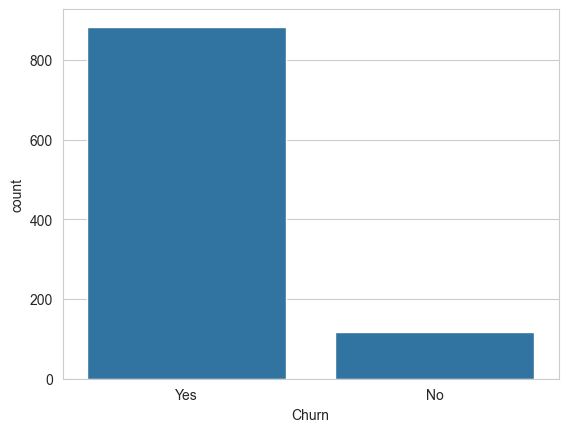

In [1126]:
#CHECKING COUNTPLOT FOR THE DEPENDENT VARIABLE
import seaborn as sns
sns.set_style("whitegrid")
sns.countplot(x = 'Churn', data = df)

#### Relationship between dependent and independent feature

Question: Do churned customers pay higher average monthly charges than retained customers?

In [1127]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

Question: What is the total monthly charges across churn status and gender groups?

In [1128]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].sum()

Churn  Gender
No     Female     4426.25
       Male       2891.68
Yes    Female    35238.28
       Male      31835.08
Name: MonthlyCharges, dtype: float64

Question: What is the average monthly charges across churn status and gender groups?

In [1129]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

Question: What is the average tenure of customers who churned compared to retained customers?

In [1130]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [1131]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


Question : What's the relationship between average customer age and churn?

In [1132]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

Question : How do average monthly charges vary across contract types?

In [1133]:
# Relationship beween dependent features
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

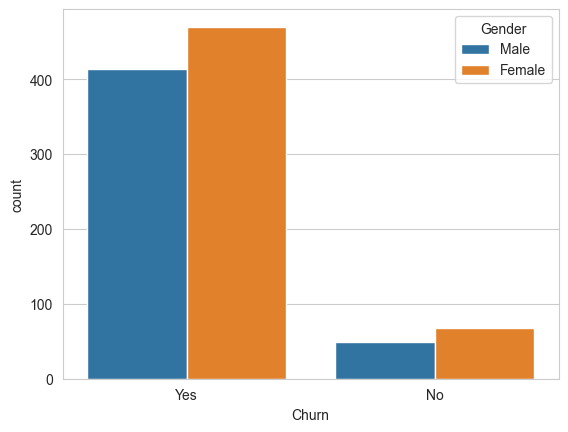

In [1134]:
import seaborn as sns
sns.set_style("whitegrid")
sns.countplot(x = 'Churn', hue = 'Gender', data = df)


Observation: Female customers exhibit a higher likelihood of churn compared to male customers.

#### Declare Feature Vector and Target Variable

In [1135]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [1136]:
df.drop('CustomerID', axis = 1, inplace = True)

In [1137]:
df.head(2)

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [1138]:
y = df['Churn']
X = df[['Age','Gender','Tenure','MonthlyCharges','ContractType','TechSupport']]

Encoding using Lambda function

In [1139]:
X["Gender"] = X["Gender"].apply(lambda x:1 if x == "Female" else 0 )

In [1140]:
X.head(5)

,Age,Gender,Tenure,MonthlyCharges,ContractType,TechSupport
0,49,0,4,88.35,Month-to-Month,Yes
1,43,0,0,36.67,Month-to-Month,Yes
2,51,1,2,63.79,Month-to-Month,No
3,60,1,8,102.34,One-Year,Yes
4,42,0,32,69.01,Month-to-Month,No


In [1141]:
type(X["Gender"][0])

numpy.int64

In [1142]:
X.TechSupport.value_counts()

TechSupport
Yes    506
No     494
Name: count, dtype: int64

In [1143]:
X["TechSupport"] = X["TechSupport"].apply(lambda x:1 if x == "Yes" else 0 )

In [1144]:
type(X["TechSupport"][0])

numpy.int64

In [1145]:
X.head(2)

,Age,Gender,Tenure,MonthlyCharges,ContractType,TechSupport
0,49,0,4,88.35,Month-to-Month,1
1,43,0,0,36.67,Month-to-Month,1


### Ordinal Encoding Technique

In [1146]:
X.ContractType.value_counts()

ContractType
Month-to-Month    511
One-Year          289
Two-Year          200
Name: count, dtype: int64

In [1147]:
from sklearn.preprocessing import OrdinalEncoder
contract_order = [['Month-to-Month','One-Year','Two-Year']]

encoder = OrdinalEncoder(categories = contract_order)
#Applying encoding to contractType column only
X['ContractType'] = encoder.fit_transform(X[['ContractType']])
print("\nEncoded ContractType values :")
print(X['ContractType'].value_counts())


Encoded ContractType values :
ContractType
0.0    511
1.0    289
2.0    200
Name: count, dtype: int64


In [1148]:
df.Churn.value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [1149]:
y.head()

0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Churn, dtype: str

In [1150]:
y = y.apply(lambda x:1 if x == "Yes" else 0 )

In [1151]:
type(y[0])

numpy.int64

In [1152]:
X.head(5)

,Age,Gender,Tenure,MonthlyCharges,ContractType,TechSupport
0,49,0,4,88.35,0.0,1
1,43,0,0,36.67,0.0,1
2,51,1,2,63.79,0.0,0
3,60,1,8,102.34,1.0,1
4,42,0,32,69.01,0.0,0


#### Split Data Into Seperate Training and Test Set

In [1153]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3)

Feature Scaling

In [1154]:
X_train.head(3)

,Age,Gender,Tenure,MonthlyCharges,ContractType,TechSupport
198,45,1,14,89.31,1.0,0
283,32,1,20,74.33,1.0,1
843,48,1,1,80.09,2.0,0


In [1155]:
from sklearn.preprocessing import StandardScaler
# Initializing the scaler
scaler = StandardScaler()

In [1156]:
X_train = scaler.fit_transform(X_train)

In [1157]:
X_train

array([[ 0.07570785,  0.92561543, -0.23166044,  0.58217512,  0.3896392 ,
        -0.99714693],
       [-1.2646451 ,  0.92561543,  0.10086651,  0.00368521,  0.3896392 ,
         1.00286124],
       [ 0.38502007,  0.92561543, -0.9521355 ,  0.22612192,  1.65823193,
        -0.99714693],
       ...,
       [ 0.28191599,  0.92561543, -0.50876623, -1.63562699,  0.3896392 ,
         1.00286124],
       [-0.54291659,  0.92561543, -0.50876623,  0.55012261,  1.65823193,
        -0.99714693],
       [-1.57395732,  0.92561543, -0.56418739,  1.08536094,  1.65823193,
         1.00286124]], shape=(700, 6))

In [1158]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [1159]:
X_test = scaler.fit_transform(X_test)

In [1160]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [1161]:
import warnings
warnings.filterwarnings("ignore")

#### LogisticsRegression model

In [1162]:
# Initialize and fit the Logistic regression model
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [1163]:
# Make predictions on the test set
y_pred = log_model.predict(X_test)

Model Evaluation

In [1164]:
from sklearn.metrics import accuracy_score
from sklearn import metrics
acc_lr = round(metrics.accuracy_score(y_test,y_pred)*100,2)
print('Model accuracy score for Logistic Regression:',acc_lr)

Model accuracy score for Logistic Regression: 89.67


In [1165]:
print(y.unique())

[1 0]


The Churn output label is [1,0] but we will make use of labels = [0,1] in classification_report because classification_report() sorts labels in ascending order by default

In [1166]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=['No','Yes']
))

              precision    recall  f1-score   support

          No       0.69      0.51      0.59        43
         Yes       0.92      0.96      0.94       257

    accuracy                           0.90       300
   macro avg       0.80      0.74      0.76       300
weighted avg       0.89      0.90      0.89       300



Interpretation : The model is very good at identifying "Yes" customers that wil churn but weak at detecting "No" customers.

#### K-Nearest Neighbour

In [1167]:
from sklearn.neighbors import KNeighborsClassifier
# Create a KNN Classifier
knn = KNeighborsClassifier()

In [1168]:
# Hyperparameter Optimization
parameters = {
              'n_neighbors': [3, 5, 7, 9],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto','ball_tree','kd_tree','brute'],
              'leaf_size': [10, 20, 30, 50]
             }

#  Run the Grid Search
from sklearn.model_selection import GridSearchCV
grid_knn = GridSearchCV(knn,parameters) # By default cross validation (CV)=5 in GridSearchCv function 
grid_knn.fit(X_train, y_train)

# Set the clf to the best combination of parameters
knn = grid_knn.best_estimator_

#Train the best model 
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",10
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [1169]:
grid_knn.best_params_

{'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 7, 'weights': 'distance'}

In [1170]:
# Prediction on test set
y_pred = knn.predict(X_test)

Model Evaluation

In [1171]:
from sklearn.metrics import accuracy_score
from sklearn import metrics
acc_knc = round(metrics.accuracy_score(y_test,y_pred)*100,2)
print('Model accuracy score for KNeighbors:',acc_knc)

Model accuracy score for KNeighbors: 94.0


In [1172]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=['No','Yes']
))

              precision    recall  f1-score   support

          No       0.82      0.74      0.78        43
         Yes       0.96      0.97      0.97       257

    accuracy                           0.94       300
   macro avg       0.89      0.86      0.87       300
weighted avg       0.94      0.94      0.94       300



#### Support Vector classifier 

In [1173]:
from sklearn import svm
# Create a support vector classifier
svc = svm.SVC()

In [1174]:
# Hyperparameter Optimization
parameters = {
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linear","rb","poly"]
}

#  Run the Grid Search
from sklearn.model_selection import GridSearchCV
grid_svc = GridSearchCV(svc,parameters) # By default cross validation (CV)=5 in GridSearchCv function 
grid_svc.fit(X_train, y_train)

# Set the svc to the best combination of parameters
svc = grid_svc.best_estimator_

#Train the best model 
svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [1175]:
grid_svc.best_params_

{'C': 1, 'kernel': 'poly'}

In [1176]:
# Prediction on test set
y_pred = svc.predict(X_test)

Model Evaluation

In [1177]:
from sklearn.metrics import accuracy_score
from sklearn import metrics
acc_svc = round(metrics.accuracy_score(y_test,y_pred)*100,2)
print('Model accuracy score for support vector classifier:',acc_svc)

Model accuracy score for support vector classifier: 92.67


In [1178]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=['No','Yes']
))

              precision    recall  f1-score   support

          No       0.96      0.51      0.67        43
         Yes       0.92      1.00      0.96       257

    accuracy                           0.93       300
   macro avg       0.94      0.75      0.81       300
weighted avg       0.93      0.93      0.92       300



#### Decision Tree Classifier

In [1179]:
from sklearn.tree import DecisionTreeClassifier
#Create a Decision Tree Classifier model
clf = DecisionTreeClassifier()

In [1180]:
# Hyperparameter Optimization
parameters = {'max_features': ['log2','sqrt','auto'],
              'criterion': ['entropy','gini'],
              'splitter' : ['best','random'],
              'max_depth': [None,5,10,20,],
              'min_samples_split': [2,5,10],
              'min_samples_leaf' : [1,2,4]
             }

#  Run the Grid Search
from sklearn.model_selection import GridSearchCV
grid_clf = GridSearchCV(clf,parameters) # By default cross validation (CV)=5 in GridSearchCv function 
grid_clf.fit(X_train, y_train)

# Set the clf to the best combination of parameters
clf = grid_clf.best_estimator_

#Train the best model 
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [1181]:
grid_clf.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

In [1182]:
# Prediction on test set
y_pred = clf.predict(X_test)

Model Evaluation

In [1183]:
from sklearn.metrics import accuracy_score
from sklearn import metrics
acc_dt = round(metrics.accuracy_score(y_test,y_pred)*100,2)
print('Model accuracy score for Decision Tree:',acc_dt)

Model accuracy score for Decision Tree: 92.67


In [1184]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=['No','Yes']
))

              precision    recall  f1-score   support

          No       0.84      0.60      0.70        43
         Yes       0.94      0.98      0.96       257

    accuracy                           0.93       300
   macro avg       0.89      0.79      0.83       300
weighted avg       0.92      0.93      0.92       300



#### Random Forest Classifier

In [1185]:
from sklearn.ensemble import RandomForestClassifier
#Create a Random Forest Classifier model
rf = RandomForestClassifier()

In [ ]:
# Hyperparameter Optimization
parameters = {'n_estimators': [32,64,128,256],
              'max_features': [2,3,4],
              'bootstrap' : [True,False]
             }

#  Run the Grid Search
from sklearn.model_selection import GridSearchCV
grid_rf = GridSearchCV(rf,parameters) # By default cross validation (CV)=5 in GridSearchCv function 
grid_rf.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf = grid_rf.best_estimator_

#Train the best model
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",32
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [1187]:
grid_rf.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 32}

In [1188]:
# Prediction on test set
y_pred = rf.predict(X_test)

In [1189]:
from sklearn.metrics import accuracy_score
from sklearn import metrics
acc_rf = round(metrics.accuracy_score(y_test,y_pred)*100,2)
print('Model accuracy score for Randomm Forest:',acc_rf)

Model accuracy score for Randomm Forest: 97.0


In [1190]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=['No','Yes']
))

              precision    recall  f1-score   support

          No       1.00      0.79      0.88        43
         Yes       0.97      1.00      0.98       257

    accuracy                           0.97       300
   macro avg       0.98      0.90      0.93       300
weighted avg       0.97      0.97      0.97       300



#### Evaluation and comparison for all model

In [1191]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbour','Support vector classifier','Decision Tree Classifier', 'Random Forest classifier'],
    'score': [acc_lr,acc_knc,acc_svc,acc_dt,acc_rf]})
models.sort_values(by='score',ascending=False)

,Model,score
4,Random Forest classifier,97.00
1,K-Nearest Neighbour,94.00
2,Support vector classifier,92.67
3,Decision Tree Classifier,92.67
0,Logistic Regression,89.67


In [1192]:
best_model = grid_rf.best_estimator_

In [1193]:
joblib.dump(best_model,"model.pkl")

['model.pkl']